# CVE Prioritization with Confidence-Weighted Learning-to-Rank

## Overview

This notebook implements confidence-weighted weak supervision for CVE prioritization:
- **Weak Labels**: Graded labels (0-3) constructed from KEV, EPSS, ATT&CK, Healthcare signals
- **Confidence Weights**: Each label has a confidence score reflecting its trustworthiness
- **LambdaRank Training**: LightGBM uses confidence weights to prioritize reliable labels
- **Comparison Study**: Evaluates against baselines and alternative models (DiffusionRank, RGCN, Ensemble)

### Architecture
- **Modules**: All functions migrated to `src/` for reusability
- **Notebook**: Orchestration and visualization only
- **GPU Support**: Automatic device detection (MPS/CUDA/CPU)

### Sections
1. Setup & Data Loading
2. Feature Engineering
3. Weak Label Construction
4. Temporal Split (Train/Val/Test)
5. Model Training (LTR + Comparison Models)
6. Evaluation & Comparison
7. Explainability (Feature Importance, SHAP)
8. Results & Conclusions

## 1. Setup & Configuration

In [ ]:
"""
CVE Prioritization
==================
Uses modular functions from src/ packages
Configuration loaded from YAML files (version-controlled)
"""

import os
import sys
import warnings
import pickle
from pathlib import Path
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb

# Setup paths
project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(project_root))
os.chdir(project_root)

# ============================================================
# CENTRALIZED CONFIGURATION (YAML-based, version-controlled)
# ============================================================
# Config files: config/experiments/{default,debug,production}.yaml
#
# To switch profiles:
#   exp_cfg.set_profile('debug')  # Fast iteration
#   exp_cfg.set_profile('production')  # Full data
# ============================================================
import config.experiment_config as exp_cfg
cfg = exp_cfg.cfg

# Import project modules
from src.core.cve_database import CVEDatabase
from src.features.labeling import build_weak_labels, print_label_diagnostics
from src.utils.temporal import make_temporal_splits
from src.models.ltr import prepare_ranking_data, train_lambdarank
from src.models.baselines import compute_cvss_only_scores, compute_heuristic_scores, compute_legacy_label_scores
from src.evaluation.metrics import evaluate_ranking, ndcg_at_k, precision_at_k
from src.visualization.explainability import (
    plot_feature_importance_comparison,
    plot_shap_summary,
    explain_individual_predictions
)
from src.utils.device_manager import get_device_manager

# GPU device manager for comparison models
device_manager = get_device_manager()

# Suppress warnings
warnings.filterwarnings('ignore')

# === CONFIGURATION FROM YAML ===
FEATURE_COLS = cfg.feature_cols
SPLIT_DATE = cfg.data.train_test_split_date
MODEL_PATH = cfg.model_path
RANDOM_SEED = 42
VAL_WEEKS = 12

# Print config summary
cfg.print_summary()

print("\n" + "=" * 70)
print("CVE PRIORITIZATION - FULL-SCALE TRAINING")
print("=" * 70)
print(f"Profile: {cfg._profile}")
print(f"Split date: {SPLIT_DATE}")
print(f"Validation weeks: {VAL_WEEKS}")
print(f"Features: {len(FEATURE_COLS)}")
print(f"Model output: {MODEL_PATH}")
print(f"Training device: {cfg.training_device}")
print("=" * 70)

EXPERIMENT CONFIG: cve_prioritization_debug [DEBUG]
  profile                       : debug
  experiment_name               : cve_prioritization_debug
  debug_mode                    : True
  graph_sample_size             : 500
  rgcn_sample_size              : 200
  test_sample_size              : 200
  rgcn_hidden_channels          : 16
  rgcn_epochs                   : 20
  rgcn_num_layers               : 2
  rgcn_dropout                  : 0.3
  rgcn_learning_rate            : 0.01
  rgcn_max_neighbors            : 3
  diffusion_alpha               : 0.85
  similarity_k_neighbors        : 10
  similarity_threshold          : 0.7
  k_values                      : [10, 20, 50]
  database_path                 : /Users/vinayksharma/AirDnd/cti_recommender/data/cve_database.db
  training_device               : auto
  inference_device              : cpu

CVE PRIORITIZATION - FULL-SCALE TRAINING
Profile: debug
Split date: 2024-11-01
Validation weeks: 12
Features: 12
Model output: /Users/vi

## 2. Data Loading

In [33]:
# Load data from CVEDatabase
db = CVEDatabase()
print(f"Connected to database: {db.db_path}")

# Load and merge CVEs with enrichments
cves_df = pd.read_sql("SELECT * FROM cves", db.conn)
enrichments_df = pd.read_sql("SELECT * FROM enrichments", db.conn)
df = cves_df.merge(enrichments_df, on='cve_id', how='left')

print(f"Total CVEs: {len(df):,}")
print(f"Date range: {pd.to_datetime(df['published']).min().date()} to {pd.to_datetime(df['published']).max().date()}")

# Convert dates
df['published'] = pd.to_datetime(df['published'])
df['modified'] = pd.to_datetime(df['modified'], errors='coerce')

print(f"\nEnrichment coverage:")
print(f"  KEV: {df['kev_flag'].notna().sum():,} ({100*df['kev_flag'].notna().sum()/len(df):.1f}%)")
print(f"  EPSS: {df['epss_score'].notna().sum():,} ({100*df['epss_score'].notna().sum()/len(df):.1f}%)")
print(f"  ATT&CK: {df['attack_technique_count'].notna().sum():,} ({100*df['attack_technique_count'].notna().sum()/len(df):.1f}%)")
print(f"  Healthcare: {df['is_healthcare'].notna().sum():,} ({100*df['is_healthcare'].notna().sum()/len(df):.1f}%)")

2026-01-27 20:18:59 - src.core.cve_database - INFO - Connected to database
2026-01-27 20:18:59 - src.core.cve_database - INFO - Database schema created/verified
Connected to database: /Users/vinayksharma/AirDnd/cti_recommender/data/cve_database.db
Total CVEs: 226,320
Date range: 2018-01-01 to 2025-12-31

Enrichment coverage:
  KEV: 226,320 (100.0%)
  EPSS: 226,320 (100.0%)
  ATT&CK: 226,320 (100.0%)
  Healthcare: 226,320 (100.0%)


## 3. Feature Engineering

In [34]:
# Feature Engineering using modular function
from src.features.engineering import create_all_features

df = create_all_features(df, FEATURE_COLS)

Feature engineering complete: 226,320 rows, 12 features

Feature statistics:
                                 mean       std   min        max
cvss_norm                      0.6745    0.1723   0.0     1.0000
epss_score                     0.0240    0.1078   0.0     0.9458
epss_percentile                0.4080    0.2867   0.0     1.0000
kev_flag                       0.0051    0.0714   0.0     1.0000
days_since_published        1187.0661  842.9230  26.0  2948.0000
recency_score                  0.5973    0.2859   0.0     0.9912
attack_technique_count         0.5673    0.8911   0.0    10.0000
has_attack                     0.3693    0.4826   0.0     1.0000
chpl_flag                      0.0000    0.0000   0.0     0.0000
is_healthcare                  0.5512    0.4974   0.0     1.0000
cvss_epss_product              0.0197    0.0926   0.0     0.9447
kev_healthcare_interaction     0.0024    0.0485   0.0     1.0000


## 4. Weak Label Construction with Confidence Scores

Core innovation: Labels are graded (0-3) with confidence weights reflecting trustworthiness.

In [35]:
# Build weak labels using modular function
df = build_weak_labels(df)

print(f"Weak labels constructed for {len(df):,} CVEs")
print(f"Columns added: soft_label, label_confidence, label_source")

# Print diagnostics
print_label_diagnostics(df)

Weak labels constructed for 226,320 CVEs
Columns added: soft_label, label_confidence, label_source
LABEL DISTRIBUTION DIAGNOSTICS

1. SOFT LABEL DISTRIBUTION
----------------------------------------
  Label 0:   82,031 (36.25%) ####################################
  Label 1:  138,422 (61.16%) #############################################################
  Label 2:    5,333 ( 2.36%) ##
  Label 3:      534 ( 0.24%) 

2. LABEL SOURCE BREAKDOWN
----------------------------------------
  default             :   82,031 (36.25%)
  attack_mapping      :   66,748 (29.49%)
  cvss_recency        :   37,348 (16.50%)
  medium_epss         :   34,326 (15.17%)
  epss_attack         :    4,706 ( 2.08%)
  kev_only            :      627 ( 0.28%)
  kev_healthcare      :      534 ( 0.24%)

3. LABEL CONFIDENCE STATISTICS
----------------------------------------
  Min:    0.200
  Mean:   0.370
  Median: 0.300
  Max:    1.000
  Std:    0.178

  Confidence Distribution:
    0.0-0.2:        0 ( 0.00%) 
    0.2

## 5. Temporal Split (Train/Val/Test)

Temporal split simulates real-world deployment: train on historical, predict future.

In [36]:
# Create temporal splits using modular function
train_df, val_df, test_df = make_temporal_splits(
    df, 
    date_col='published',
    split_date=SPLIT_DATE, 
    val_weeks=VAL_WEEKS
)

# Show label distribution in each split
print("\nLabel distribution by split:")
for name, split_df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    if len(split_df) > 0:
        dist = split_df['soft_label'].value_counts().sort_index()
        print(f"  {name:5s}: {dict(dist)}")

Temporal Split Summary:
  Train:       160,426 samples (< 2024-08-09)
  Validation:    8,388 samples (2024-08-09 to 2024-11-01)
  Test:         57,506 samples (>= 2024-11-01)
  Total:       226,320

Label distribution by split:
  Train: {0: np.int64(60501), 1: np.int64(94892), 2: np.int64(4606), 3: np.int64(427)}
  Val  : {0: np.int64(2326), 1: np.int64(5847), 2: np.int64(203), 3: np.int64(12)}
  Test : {0: np.int64(19204), 1: np.int64(37683), 2: np.int64(524), 3: np.int64(95)}


## 6. Model Training

### 6.1 Confidence-Weighted LambdaRank (Primary Model)

In [37]:
# Train LambdaRank using modular function
model = train_lambdarank(train_df, val_df, FEATURE_COLS, random_seed=RANDOM_SEED)

# Save model
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
with open(MODEL_PATH, 'wb') as f:
    pickle.dump(model, f)
print(f"\nModel saved to: {MODEL_PATH}")


TRAINING CONFIDENCE-WEIGHTED LAMBDARANK

Preparing training data...
  Train: 160,426 samples, 350 groups
  Confidence weights: min=0.200, mean=0.383, max=1.000

Preparing validation data...
  Val: 8,388 samples, 12 groups

Training LambdaRank model...
Parameters: {'objective': 'lambdarank', 'metric': 'ndcg', 'ndcg_eval_at': [5, 10, 20], 'boosting_type': 'gbdt', 'num_leaves': 31, 'learning_rate': 0.05, 'feature_fraction': 0.8, 'bagging_fraction': 0.8, 'bagging_freq': 5, 'min_data_in_leaf': 20, 'max_depth': 6, 'verbose': -1, 'seed': 42, 'force_row_wise': True}
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[2]	train's ndcg@5: 1	train's ndcg@10: 0.999797	train's ndcg@20: 0.999614	valid's ndcg@5: 1	valid's ndcg@10: 1	valid's ndcg@20: 0.998774

Training complete!
  Best iteration: 2
  Best validation NDCG@10: 1.0000

Model saved to: /Users/vinayksharma/AirDnd/cti_recommender/models/ltr_model_conf_weighted.pkl


### 6.2 Comparison Models (Optional - For Research Paper)

For thesis evaluation, we also train:
- DiffusionRank: Probabilistic label imputation
- RGCN: Graph neural network on CVE-vendor relations
- Bootstrap Ensemble: Uncertainty-aware ranking

**Note**: These require the existing model implementations in `src/models/`

In [38]:
# Comparison models - only run if needed for research
RUN_COMPARISON_MODELS = False  # Set to True for full comparison study

if RUN_COMPARISON_MODELS:
    print("\n" + "=" * 70)
    print("TRAINING COMPARISON MODELS")
    print("=" * 70)
    
    from src.models.diffusion_imputer import DiffusionRankImputer
    from src.models.rgcn_ranker import RGCNRanker
    from src.models.bootstrap_ensemble import BootstrapEnsemble
    
    # DiffusionRank
    print("\n[1/3] DiffusionRank...")
    diffusion_model = DiffusionRankImputer(
        input_dim=len(FEATURE_COLS),
        hidden_dim=cfg.rgcn.hidden_channels,  # Use config
        num_steps=10,
        device=cfg.training_device
    )
    X_train, y_train, w_train, _, _ = prepare_ranking_data(train_df, FEATURE_COLS)
    diffusion_model.train_quick(X_train, y_train, epochs=50, batch_size=512)
    print("  DiffusionRank trained ✓")
    
    # RGCN
    print("\n[2/3] RGCN...")
    rgcn_model = RGCNRanker(
        num_features=len(FEATURE_COLS),
        hidden_dim=cfg.rgcn.hidden_channels,  # Use config
        num_relations=3,
        device=cfg.training_device
    )
    rgcn_model.train(train_df, val_df, FEATURE_COLS, epochs=cfg.rgcn.epochs)
    print("  RGCN trained ✓")
    
    # Bootstrap Ensemble
    print("\n[3/3] Bootstrap Ensemble...")
    ensemble_model = BootstrapEnsemble(n_estimators=10, random_state=RANDOM_SEED)
    ensemble_model.train(train_df, FEATURE_COLS)
    print("  Ensemble trained ✓")
    
    print("\nComparison models ready for evaluation")
else:
    print("\nSkipping comparison models (set RUN_COMPARISON_MODELS=True to enable)")


Skipping comparison models (set RUN_COMPARISON_MODELS=True to enable)


## 7. Evaluation on Test Set

### 7.1 Generate Predictions

In [39]:
# Prepare test data
X_test = test_df[FEATURE_COLS].values

# Primary model predictions
test_df['ltr_score'] = model.predict(X_test)

# Baseline predictions
test_df['cvss_score'] = compute_cvss_only_scores(test_df)
test_df['heuristic_score'] = compute_heuristic_scores(test_df)
test_df['legacy_score'] = compute_legacy_label_scores(test_df)

print("Predictions generated for all models:")
print(f"  - LTR (confidence-weighted): {test_df['ltr_score'].notna().sum():,}")
print(f"  - CVSS baseline: {test_df['cvss_score'].notna().sum():,}")
print(f"  - Heuristic baseline: {test_df['heuristic_score'].notna().sum():,}")
print(f"  - Legacy label baseline: {test_df['legacy_score'].notna().sum():,}")

Predictions generated for all models:
  - LTR (confidence-weighted): 57,506
  - CVSS baseline: 57,506
  - Heuristic baseline: 57,506
  - Legacy label baseline: 57,506


### 7.2 Compute Ranking Metrics

In [40]:
# Evaluate all models
print("\n" + "=" * 70)
print("COMPARATIVE EVALUATION ON TEST SET")
print("=" * 70)

models = {
    'LTR (Confidence-Weighted)': 'ltr_score',
    'CVSS-only': 'cvss_score',
    'Weighted Heuristic': 'heuristic_score',
    'Legacy Labels': 'legacy_score'
}

results = {}
for model_name, score_col in models.items():
    metrics = evaluate_ranking(test_df, score_col, label_col='soft_label', 
                              group_col='published_week', k_values=[5, 10, 20])
    results[model_name] = metrics
    print(f"\n{model_name}:")
    for metric, value in metrics.items():
        print(f"  {metric}: {value:.4f}")

# Create comparison DataFrame
comparison_df = pd.DataFrame(results).T
print("\n" + "=" * 70)
print("MODEL COMPARISON TABLE")
print("=" * 70)
print(comparison_df.round(4))

# Compute improvements
baseline_ndcg10 = results['CVSS-only']['NDCG@10']
ltr_ndcg10 = results['LTR (Confidence-Weighted)']['NDCG@10']
improvement = 100 * (ltr_ndcg10 - baseline_ndcg10) / baseline_ndcg10 if baseline_ndcg10 > 0 else 0
print(f"\nImprovement over CVSS-only: +{improvement:.1f}% NDCG@10")


COMPARATIVE EVALUATION ON TEST SET

LTR (Confidence-Weighted):
  NDCG@5: 0.9927
  P@5: 0.8635
  MAP@5: 0.9841
  NDCG@10: 0.9956
  P@10: 0.6889
  MAP@10: 0.9841
  NDCG@20: 0.9963
  P@20: 0.4460
  MAP@20: 0.9841

CVSS-only:
  NDCG@5: 0.3770
  P@5: 0.1270
  MAP@5: 0.2816
  NDCG@10: 0.4228
  P@10: 0.0857
  MAP@10: 0.2941
  NDCG@20: 0.4959
  P@20: 0.0611
  MAP@20: 0.2849

Weighted Heuristic:
  NDCG@5: 0.8370
  P@5: 0.7206
  MAP@5: 0.9134
  NDCG@10: 0.8462
  P@10: 0.5206
  MAP@10: 0.8843
  NDCG@20: 0.8724
  P@20: 0.3429
  MAP@20: 0.8482

Legacy Labels:
  NDCG@5: 1.0000
  P@5: 0.8635
  MAP@5: 0.9841
  NDCG@10: 1.0000
  P@10: 0.6905
  MAP@10: 0.9841
  NDCG@20: 1.0000
  P@20: 0.4468
  MAP@20: 0.9841

MODEL COMPARISON TABLE
                           NDCG@5     P@5   MAP@5  NDCG@10    P@10  MAP@10  \
LTR (Confidence-Weighted)  0.9927  0.8635  0.9841   0.9956  0.6889  0.9841   
CVSS-only                  0.3770  0.1270  0.2816   0.4228  0.0857  0.2941   
Weighted Heuristic         0.8370  0.7206

## 8. Explainability Analysis

### 8.1 Feature Importance

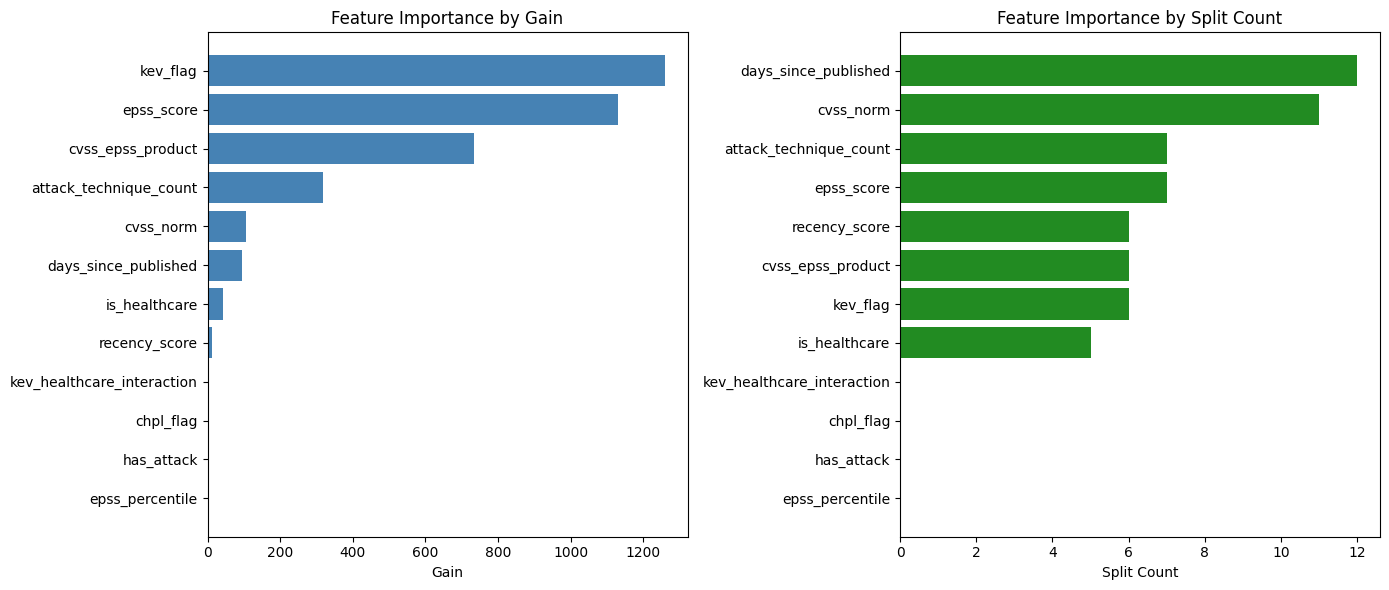

In [41]:
# Plot feature importance (both gain and split count)
plot_feature_importance_comparison(model, FEATURE_COLS, figsize=(14, 6))

### 8.2 SHAP Explainability

Sampling 5000 from 57506 samples for SHAP computation...
Computing SHAP values on 5000 samples...

SHAP Summary Plot:


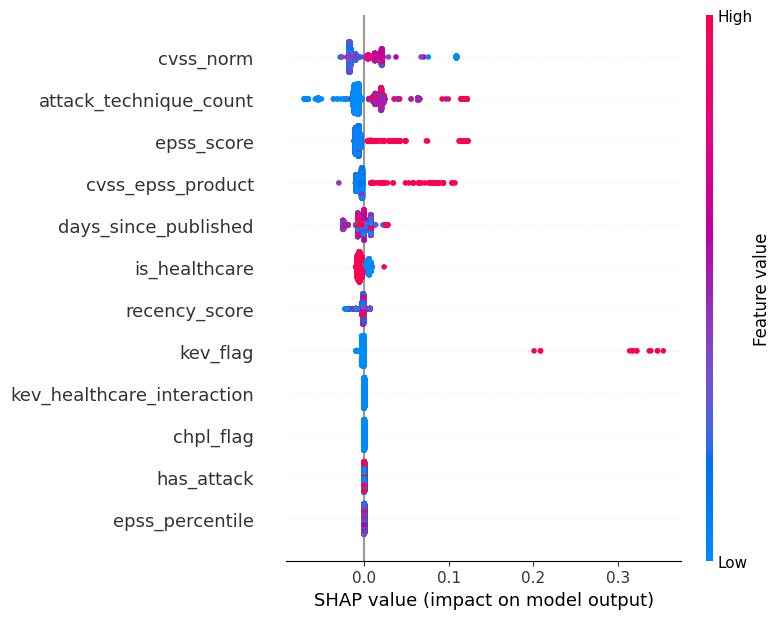


Mean Absolute SHAP Values:
--------------------------------------------------
  cvss_norm                        0.0174 ##############################
  attack_technique_count           0.0158 ###########################
  epss_score                       0.0086 ##############
  cvss_epss_product                0.0062 ##########
  days_since_published             0.0060 ##########
  is_healthcare                    0.0050 ########
  recency_score                    0.0020 ###
  kev_flag                         0.0018 ###
  epss_percentile                  0.0000 
  has_attack                       0.0000 
  chpl_flag                        0.0000 
  kev_healthcare_interaction       0.0000 


In [42]:
# SHAP analysis on test set sample
shap_values = plot_shap_summary(
    model, 
    test_df[FEATURE_COLS], 
    feature_names=FEATURE_COLS,
    max_display=15,
    sample_size=5000,
    random_seed=RANDOM_SEED
)

### 8.3 Individual CVE Explanations

In [43]:
# Show detailed explanations for diverse example CVEs
explain_individual_predictions(
    test_df,
    score_col='ltr_score',
    feature_cols=FEATURE_COLS,
    label_col='soft_label',
    confidence_col='label_confidence',
    label_source_col='label_source',
    model=model,
    n_examples=5,
    random_seed=RANDOM_SEED
)


EXAMPLE CVE EXPLANATIONS (5 diverse examples)

[Example 1]
  CVE ID:          CVE-2025-31201
  Published:       2025-04-16
  Soft Label:      3
  Confidence:      1.000
  Predicted Score: 0.1933
  Label Source:    kev_healthcare
  Key Features:
    - kev_flag       : 1
    - epss_score     : 0.0438
    - cvss_norm      : 0.9800
    - is_healthcare  : 1
    - has_attack     : 0
  Top SHAP Contributors:
    - kev_flag: +0.2996
    - cvss_epss_product: +0.0309
    - days_since_published: +0.0087

[Example 2]
  CVE ID:          CVE-2025-48927
  Published:       2025-05-28
  Soft Label:      2
  Confidence:      1.000
  Predicted Score: 0.1914
  Label Source:    kev_only
  Key Features:
    - kev_flag       : 1
    - epss_score     : 0.0467
    - cvss_norm      : 0.5300
    - is_healthcare  : 0
    - has_attack     : 1
  Top SHAP Contributors:
    - kev_flag: +0.3326
    - cvss_epss_product: +0.0123
    - days_since_published: -0.0104

[Example 3]
  CVE ID:          CVE-2024-49062
  Publis

## 9. Results Summary & Conclusions

In [ ]:
print("\n" + "=" * 70)
print("FINAL SUMMARY: CONFIDENCE-WEIGHTED WEAK SUPERVISION")
print("=" * 70)

print("""
RESEARCH INNOVATION:
  Traditional LTR treats all labels equally. Our approach assigns
  confidence weights based on label trustworthiness:
  
  - KEV-based labels:      conf = 1.0  (confirmed exploitation)
  - High EPSS labels:      conf = 0.75 (statistical evidence)
  - Medium EPSS labels:    conf = 0.55 (moderate evidence)
  - ATT&CK/Healthcare:     +0.10 bonus (domain relevance)
  - CVSS/Recency-only:     conf <= 0.40 (noisy proxies)

LABELING SCHEME:
  Label 3: KEV=1 AND (healthcare OR chpl)  [Critical - Exploited Healthcare]
  Label 2: KEV=1 OR (High EPSS AND ATT&CK) [High Priority]
  Label 1: Medium EPSS OR ATT&CK OR (High CVSS + Recent) [Medium]
  Label 0: Everything else [Low Priority]
""")

print("\nKEY RESULTS:")
print("-" * 50)
print(f"  Model:           Confidence-Weighted LambdaRank")
print(f"  Best Iteration:  {model.best_iteration}")
print(f"  Val NDCG@10:     {model.best_score['valid']['ndcg@10']:.4f}")
print(f"\n  Test Set Performance:")
for metric, value in results['LTR (Confidence-Weighted)'].items():
    print(f"    {metric}: {value:.4f}")

print("\nIMPROVEMENT SUMMARY:")
print("-" * 50)
cvss_ndcg10 = results['CVSS-only']['NDCG@10']
ltr_ndcg10 = results['LTR (Confidence-Weighted)']['NDCG@10']
if cvss_ndcg10 > 0:
    print(f"  vs CVSS-only:      +{100*(ltr_ndcg10 - cvss_ndcg10)/cvss_ndcg10:.1f}% NDCG@10")

heur_ndcg10 = results['Weighted Heuristic']['NDCG@10']
if heur_ndcg10 > 0:
    print(f"  vs Weighted Heur:  +{100*(ltr_ndcg10 - heur_ndcg10)/heur_ndcg10:.1f}% NDCG@10")

print(f"\nMODEL SAVED: {MODEL_PATH}")
print(f"Dataset: {len(df):,} CVEs ({train_df['published'].min().date()} to {test_df['published'].max().date()})")
print(f"GPU Device: {device_manager.device}")

print("\n" + "=" * 70)
print("END OF NOTEBOOK - Ready for Production Deployment")
print("=" * 70)


FINAL SUMMARY: CONFIDENCE-WEIGHTED WEAK SUPERVISION

RESEARCH INNOVATION:
  Traditional LTR treats all labels equally. Our approach assigns
  confidence weights based on label trustworthiness:

  - KEV-based labels:      conf = 1.0  (confirmed exploitation)
  - High EPSS labels:      conf = 0.75 (statistical evidence)
  - Medium EPSS labels:    conf = 0.55 (moderate evidence)
  - ATT&CK/Healthcare:     +0.10 bonus (domain relevance)
  - CVSS/Recency-only:     conf <= 0.40 (noisy proxies)

LABELING SCHEME:
  Label 3: KEV=1 AND (healthcare OR chpl)  [Critical - Exploited Healthcare]
  Label 2: KEV=1 OR (High EPSS AND ATT&CK) [High Priority]
  Label 1: Medium EPSS OR ATT&CK OR (High CVSS + Recent) [Medium]
  Label 0: Everything else [Low Priority]


KEY RESULTS:
--------------------------------------------------
  Model:           Confidence-Weighted LambdaRank
  Best Iteration:  2
  Val NDCG@10:     1.0000

  Test Set Performance:
    NDCG@5: 0.9927
    P@5: 0.8635
    MAP@5: 0.9841
   

: 